# 242. Valid Anagram
https://leetcode.com/problems/valid-anagram/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Sorting | O(n log n) | O(n) | Sort both strings, compare |
| **Hash Map / Array Count** | **O(n)** | **O(1)** | **Count character frequencies, compare** |

## Methodology

We use a **frequency count** array of size 26 (for lowercase English letters). Increment for each character in `s`, decrement for each character in `t`. If all counts are zero at the end, the strings are anagrams. This runs in O(n) time with O(1) space (fixed 26-element array).

## Solutions

### C#

In [ ]:
// 242. Valid Anagram
// Time: O(n) | Space: O(1)
public class Solution {
    public bool IsAnagram(string s, string t) {
        if (s.Length != t.Length) return false;
        
        int[] count = new int[26];
        for (int i = 0; i < s.Length; i++) {
            count[s[i] - 'a']++;
            count[t[i] - 'a']--;
        }
        
        foreach (int c in count)
            if (c != 0) return false;
        return true;
    }
}

### Python

In [ ]:
# 242. Valid Anagram
# Time: O(n) | Space: O(1)
from collections import Counter

class Solution:
    def isAnagram(self, s: str, t: str) -> bool:
        return Counter(s) == Counter(t)

### Go

In [ ]:
// 242. Valid Anagram
// Time: O(n) | Space: O(1)
func isAnagram(s string, t string) bool {
    if len(s) != len(t) {
        return false
    }
    
    var count [26]int
    for i := 0; i < len(s); i++ {
        count[s[i]-'a']++
        count[t[i]-'a']--
    }
    
    for _, c := range count {
        if c != 0 {
            return false
        }
    }
    return true
}

### Rust

In [ ]:
// 242. Valid Anagram
// Time: O(n) | Space: O(1)
impl Solution {
    pub fn is_anagram(s: String, t: String) -> bool {
        if s.len() != t.len() {
            return false;
        }
        
        let mut count = [0i32; 26];
        for (a, b) in s.bytes().zip(t.bytes()) {
            count[(a - b'a') as usize] += 1;
            count[(b - b'a') as usize] -= 1;
        }
        
        count.iter().all(|&c| c == 0)
    }
}

## Example Scenarios

### 1. Common Case — Valid Anagram
**Input:** `s = "anagram"`, `t = "nagaram"`

Both strings have identical character frequencies: `{a:3, n:1, g:1, r:1, m:1}`. After incrementing counts for `s` and decrementing for `t`, all counters reach zero. Return `true`.

### 2. Slightly Complex — Single Character Difference
**Input:** `s = "rat"`, `t = "car"`

Frequencies differ: `s` has `{r:1, a:1, t:1}`, `t` has `{c:1, a:1, r:1}`. The counter for `t` is $+1$ and for `c` is $-1$ — a single swap changes the outcome. Return `false`.

### 3. Edge Case: Time Factor — Long Strings with Same Characters
**Input:** `s` and `t` are both $5 \times 10^4$ characters of `"a"` repeated

Two passes of $n = 5 \times 10^4$ each — one to count `s`, one to decrement for `t`. Despite the large size, the 26-element frequency array makes this $O(n)$ with tiny constant. Return `true`.

### 4. Edge Case: Space Factor — All Unique Characters
**Input:** `s = "abcdefghijklmnopqrstuvwxyz"`, `t = "zyxwvutsrqponmlkjihgfedcba"`

All 26 lowercase letters appear exactly once in both strings. The frequency array uses all 26 slots — maximum space usage for the fixed-size approach. Space is still $O(1)$ since the alphabet size is constant. Return `true`.

### 5. Almost-Impossible but Plausible — Single Character Strings
**Input:** `s = "a"`, `t = "a"`

The minimum valid input under $1 \le s.length$. Only one counter is touched: `a` goes to $+1$ then back to $0$. The algorithm handles this in $O(1)$ time with $O(1)$ space — the degenerate case where the frequency array has exactly one nonzero entry.

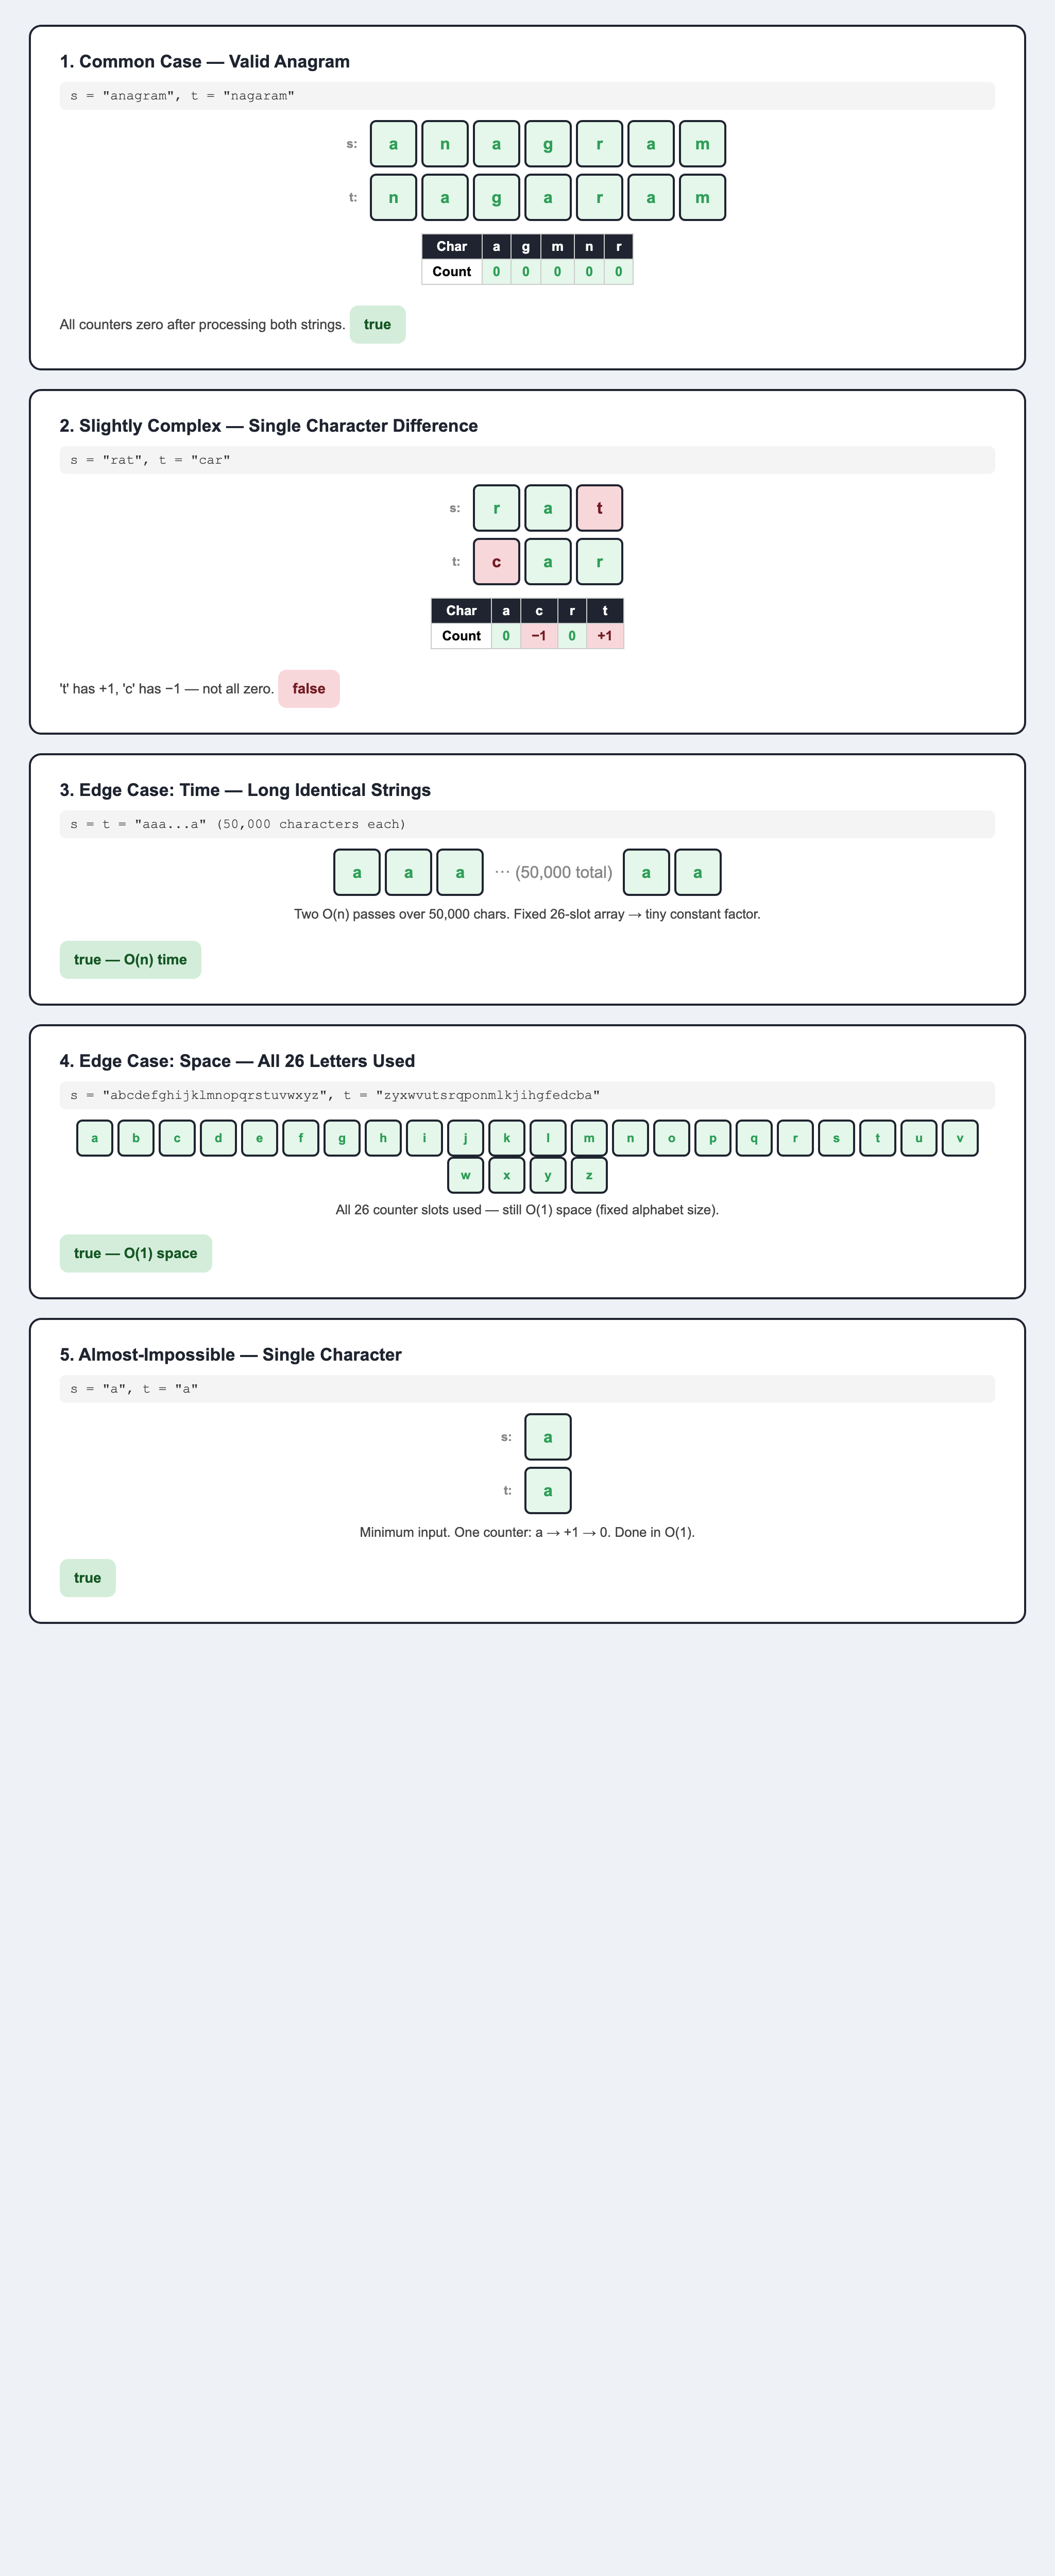